<a href="https://colab.research.google.com/github/MaxDkn/my-own-gpt/blob/dev/script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tiktoken > /dev/null

In [2]:
import re
import torch
import tiktoken
import torch.nn as nn
import urllib.request
from importlib.metadata import version
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding('gpt2')

In [3]:
#  DOWNLOAD THE DATASET AND SAVE IT TO "the-verdict.txt"
def download_data(url: str = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"):
  file_path = "the-verdict.txt"
  urllib.request.urlretrieve(url, file_path)
  with open('the-verdict.txt', 'r', encoding='utf-8') as f:
    return f.read()

raw_text = download_data()
enc_text = tokenizer.encode(raw_text)

In [4]:
GPT_CONFIG_124M = {
    'vocab_size': 50257,
    'context_lenght': 256,
    'emb_dim': 768,
    'n_heads': 12,
    'n_layers': 12,
    'drop_rate': 0.1,
    'qkv_bias': False
}

In [5]:
class GPTDatasetV1(Dataset):
  def __init__(self, txt: str, tokenizer: object, max_lenght: int, stride: int):
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    for i in range(0, len(token_ids) - max_lenght, stride):
      input_chunk = token_ids[i:i+max_lenght]
      target_chunk = token_ids[i+1:i+max_lenght+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]

In [6]:
def create_dataloader_v1(txt, batch_size=4, max_lenght=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
  tokenizer = tiktoken.get_encoding('gpt2')
  dataset = GPTDatasetV1(txt, tokenizer, max_lenght, stride)
  dataloader = DataLoader(
      dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers
  )
  return dataloader

In [7]:
max_lenght = 4
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_lenght=max_lenght, stride=4, shuffle=False)

In [8]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89],
     [0.55, 0.87, 0.66],
     [0.57, 0.85, 0.64],
     [0.22, 0.58, 0.33],
     [0.77, 0.25, 0.10],
     [0.05, 0.80, 0.55]]
)
inputs

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

In [9]:
batch = torch.stack((inputs, inputs), dim=0)

In [10]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var  = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

In [11]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
        (x + 0.044715 * torch.pow(x, 3))
    ))

In [12]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),
        GELU(),
        nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim'])
    )

  def forward(self, x):
    return self.layers(x)

In [13]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_lenght, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads

    self.W_query  = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key    = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value  = nn.Linear(d_in, d_out, bias=qkv_bias)

    self.out_proj = nn.Linear(d_in, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_lenght, context_lenght), diagonal=1)
    )

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys    = self.W_key(x)
    queries = self.W_query(x)
    values  = self.W_value(x)

    keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values  = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

    keys    = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values  = values.transpose(1, 2)

    attn_scores = queries @ keys.transpose(2, 3)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    attn_scores.masked_fill_(mask_bool, -torch.inf)
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    attn_weights = self.dropout(attn_weights)

    context_vec = (attn_weights @ values).transpose(1, 2)
    context_vec = context_vec.contiguous().view(
        b, num_tokens, self.d_out
    )
    context_vec = self.out_proj(context_vec)
    return context_vec

In [14]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(d_in           = cfg['emb_dim'],
                                  d_out          = cfg['emb_dim'],
                                  context_lenght = cfg['context_lenght'],
                                  num_heads      = cfg['n_heads'],
                                  dropout        = cfg['drop_rate'],
                                  qkv_bias       = cfg['qkv_bias'])
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg['emb_dim'])
    self.norm2 = LayerNorm(cfg['emb_dim'])
    self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.norm1(x)
    x = self.att(x)
    x = self.drop_shortcut(x)
    x = x + shortcut

    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x + shortcut
    return x

In [15]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb  = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
    self.pos_emb  = nn.Embedding(cfg['context_lenght'], cfg['emb_dim'])
    self.drop_emb = nn.Dropout(cfg['drop_rate'])

    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg['n_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_dim'])
    self.out_head = nn.Linear(
        cfg['emb_dim'], cfg['vocab_size'], bias=False
    )

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(
        torch.arange(seq_len, device=in_idx.device)
    )
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

  def get_size(self):
    total_params = sum(p.numel() for p in self.parameters())
    return {'total parameters': f"{total_params:,}",
            'size': f'{((total_params * 4) / (1024 * 1024)):.2f} MB'}

In [16]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)

    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1)
    idx_next = torch.argmax(probas, dim=-1, keepdim=True)
    idx = torch.cat((idx, idx_next), dim=1)
  return idx

In [17]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

In [19]:
total_characters = len(raw_text)
total_tokens = len(enc_text)
print('Characters:', total_characters)
print('Tokens:    ', total_tokens)

Characters: 20479
Tokens:     5145


In [20]:
train_ratio = 0.90
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]

In [21]:
torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_lenght=GPT_CONFIG_124M['context_lenght'],
    stride=GPT_CONFIG_124M['context_lenght'],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_lenght=GPT_CONFIG_124M['context_lenght'],
    stride=GPT_CONFIG_124M['context_lenght'],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [22]:
print('Train Loader:')
for x, y in train_loader:
  print(x.shape, y.shape)

print('\nValidation Loader:')
for x, y in val_loader:
  print(x.shape, y.shape)

Train Loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation Loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [23]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(
      logits.flatten(0, 1), target_batch.flatten()
  )
  return loss

In [36]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [38]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1

  for epoch in range(num_epochs):
    model.train()
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )
      loss.backward()
      optimizer.step()
      tokens_seen += input_batch.numel()
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f'Ep {epoch+1} (Step {global_step:06d}): '
              f'Train loss {train_loss:.3f} '
              f'Val loss {val_loss:.3f}')
    generate_and_print_sample(
        model, tokenizer, device, start_context
    )
  return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=eval_iter
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=eval_iter
    )
  model.train()
  return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(
        model, encoded, 50, context_size
    )
  decoded_text = token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace('\n', ' '))
  model.train()

In [39]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.818 Val loss 9.930
Ep 1 (Step 000005): Train loss 8.066 Val loss 8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.623 Val loss 7.053
Ep 2 (Step 000015): Train loss 6.047 Val loss 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.532 Val loss 6.507
Ep 3 (Step 000025): Train loss 5.399 Val loss 6.389
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
Ep 4 (Step 000030): Train loss 4.895 Val loss 6.280
Ep 4 (Step 000035): Train loss 4.648 Val loss 6.304
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 4.023 Val loss 6.165
Every effort moves you know                                                 


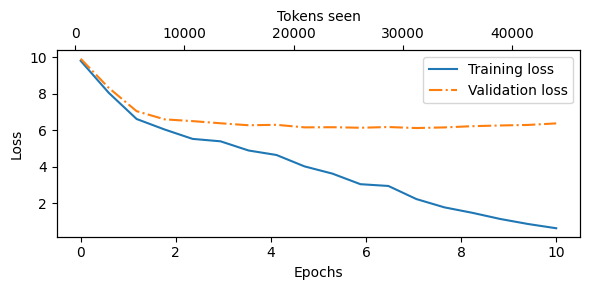

In [44]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
  fig, ax1 = plt.subplots(figsize=(6, 3))
  ax1.plot(epochs_seen, train_losses, label='Training loss')
  ax1.plot(
      epochs_seen, val_losses, linestyle='-.', label='Validation loss'
  )
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.legend(loc='upper right')
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax2 = ax1.twiny()
  ax2.plot(tokens_seen, train_losses, alpha=0)
  ax2.set_xlabel('Tokens seen')
  fig.tight_layout()
  plt.show()

assert len(train_losses) == len(val_losses) == len(tokens_seen), "Mismatch in data lengths"

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [47]:
model.to('cpu')
model.eval()
tokenizer = tiktoken.get_encoding('gpt2')
token_ids = generate_text_simple(
    model, text_to_token_ids('Every effort moves you', tokenizer), 25,
    GPT_CONFIG_124M['context_lenght']
)
print(f'Output text:\n{token_ids_to_text(token_ids, tokenizer)}')

Output text:
Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [54]:
def softmax_with_temperature(logits, temperature):
  scaled_logits = logits / temperature
  return torch.softmax(scaled_logits, dim=0)

In [60]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]
    if top_k is not None:
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(
          logits < min_val,
          torch.tensor(float('-inf')).to(logits.device),
          logits
      )
    if temperature > 0.0:
      logits = logits / temperature
      probs = torch.softmax(logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)
    if idx_next == eos_id:
      break
    idx = torch.cat((idx, idx_next), dim=1)
  return idx

In [65]:
torch.manual_seed(123)
token_ids = generate(
    model, text_to_token_ids('Every effort moves you', tokenizer),
    15, GPT_CONFIG_124M['context_lenght'], 5, 25
)
print(f'Output text:\n{token_ids_to_text(token_ids, tokenizer)}')

Output text:
Every effort moves you know Jack G to a hint a little it was such struck!; and


In [66]:
torch.save(model.state_dict(), 'model.pth')